# Question 1: Dataset Loading and Structure Analysis

In [5]:
# Import Spark Session
from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder \
    .appName("Phishing Email Detection") \
    .getOrCreate()

# Reduce Spark warnings
spark.sparkContext.setLogLevel("ERROR")

# Load dataset into first DataFrame
df1 = spark.read.csv(
    "../data/email_security_data.csv",
    header=True,
    inferSchema=True
)

print("="*60)
print("DATASET PREVIEW")
print("="*60)

df1.show(5, truncate=False)

print("\n" + "="*60)
print("DATASET STRUCTURE")
print("="*60)

for col_name, data_type in df1.dtypes:
    print(f"{col_name:<25} {data_type}")

rows = df1.count()
columns = len(df1.columns)

print("\n" + "="*60)
print("DATASET DIMENSIONS")
print("="*60)

print(f"Total Rows    : {rows}")
print(f"Total Columns : {columns}")

DATASET PREVIEW
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|EmailAttachments|URLCount|SenderReputation|SuspiciousKeywords|EmailSize|LinkEntropy|DomainRiskScore|AccountAge|PhishingLabel|
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|3               |7       |169             |1                 |259.69   |3.046      |0.239          |78        |1            |
|0               |4       |87              |7                 |322.43   |2.347      |0.494          |24        |0            |
|0               |4       |195             |1                 |92.37    |3.795      |0.583          |11        |0            |
|0               |2       |85              |0                 |447.77   |2.667      |0.123          |72        |0            |
|3               |4       |163             |4                 |294.7    |0.0        |0.889     

# Question 2: Missing Value Replacement using Median

In [11]:
from pyspark.sql.functions import when, col

print("="*60)
print("MEDIAN CALCULATION")
print("="*60)

# Calculate median excluding 0 values

suspicious_median = int(
    df1.filter(
        col("SuspiciousKeywords") != 0
    ).approxQuantile(
        "SuspiciousKeywords",
        [0.5],
        0
    )[0]
)

emailsize_median = float(
    df1.filter(
        col("EmailSize") != 0
    ).approxQuantile(
        "EmailSize",
        [0.5],
        0
    )[0]
)

print(f"Median of SuspiciousKeywords: {suspicious_median}")
print(f"Median of EmailSize: {emailsize_median}")

# Create second DataFrame

df2 = df1.withColumn(
    "SuspiciousKeywords",
    when(
        col("SuspiciousKeywords")==0,
        suspicious_median
    ).otherwise(col("SuspiciousKeywords"))
).withColumn(
    "EmailSize",
    when(
        col("EmailSize")==0,
        emailsize_median
    ).otherwise(col("EmailSize"))
)

print("\n" + "="*60)
print("UPDATED DATA PREVIEW")
print("="*60)

df2.show(10, truncate=False)

MEDIAN CALCULATION
Median of SuspiciousKeywords: 4
Median of EmailSize: 276.12

UPDATED DATA PREVIEW
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|EmailAttachments|URLCount|SenderReputation|SuspiciousKeywords|EmailSize|LinkEntropy|DomainRiskScore|AccountAge|PhishingLabel|
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|3               |7       |169             |1                 |259.69   |3.046      |0.239          |78        |1            |
|0               |4       |87              |7                 |322.43   |2.347      |0.494          |24        |0            |
|0               |4       |195             |1                 |92.37    |3.795      |0.583          |11        |0            |
|0               |2       |85              |4                 |447.77   |2.667      |0.123          |72        |0            |
|3        

# Question 3: Dataset Cleaning and Row Removal

In [12]:
from pyspark.sql.functions import col

print("="*60)
print("DATA CLEANING PROCESS")
print("="*60)

# Count rows before cleaning
rows_before = df2.count()

# Create third DataFrame by removing rows with missing values
df3 = df2.filter(
    (col("URLCount") != 0) &
    (col("SenderReputation") != 0) &
    (col("LinkEntropy") != 0)
)

# Count rows after cleaning
rows_after = df3.count()

# Calculate removed rows
rows_removed = rows_before - rows_after

percentage_removed = round(
    (rows_removed/rows_before)*100,
    2
)

print(f"Rows before cleaning : {rows_before}")
print(f"Rows after cleaning  : {rows_after}")
print(f"Rows removed         : {rows_removed}")
print(f"Percentage removed   : {percentage_removed}%")

print("\n" + "="*60)
print("CLEANED DATA PREVIEW")
print("="*60)

df3.show(10, truncate=False)

DATA CLEANING PROCESS
Rows before cleaning : 5000
Rows after cleaning  : 3847
Rows removed         : 1153
Percentage removed   : 23.06%

CLEANED DATA PREVIEW
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|EmailAttachments|URLCount|SenderReputation|SuspiciousKeywords|EmailSize|LinkEntropy|DomainRiskScore|AccountAge|PhishingLabel|
+----------------+--------+----------------+------------------+---------+-----------+---------------+----------+-------------+
|3               |7       |169             |1                 |259.69   |3.046      |0.239          |78        |1            |
|0               |4       |87              |7                 |322.43   |2.347      |0.494          |24        |0            |
|0               |4       |195             |1                 |92.37    |3.795      |0.583          |11        |0            |
|0               |2       |85              |4                 |447.77   |2.667  

# Question 4: Statistical Analysis of SenderReputation

SUMMARY STATISTICS: SenderReputation
Minimum Value         : 20
Maximum Value         : 199
Mean                  : 109.59
Median                : 110.0
Variance              : 2683.75
Standard Deviation    : 51.8

VISUALISATION


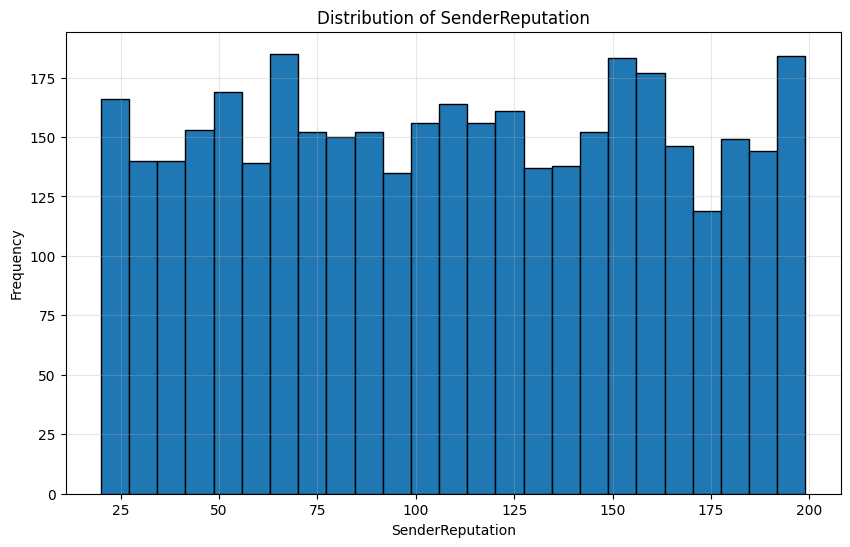

In [ ]:
from pyspark.sql.functions import min, max, mean, variance, stddev
import matplotlib.pyplot as plt

print("="*60)
print("SUMMARY STATISTICS: SenderReputation")
print("="*60)

# Calculate statistics

min_value = df3.select(
    min("SenderReputation")
).collect()[0][0]

max_value = df3.select(
    max("SenderReputation")
).collect()[0][0]

mean_value = df3.select(
    mean("SenderReputation")
).collect()[0][0]

median_value = df3.approxQuantile(
    "SenderReputation",
    [0.5],
    0
)[0]

variance_value = df3.select(
    variance("SenderReputation")
).collect()[0][0]

std_value = df3.select(
    stddev("SenderReputation")
).collect()[0][0]


print(f"Minimum Value         : {round(min_value,2)}")
print(f"Maximum Value         : {round(max_value,2)}")
print(f"Mean                  : {round(mean_value,2)}")
print(f"Median                : {round(median_value,2)}")
print(f"Variance              : {round(variance_value,2)}")
print(f"Standard Deviation    : {round(std_value,2)}")


print("\n" + "="*60)
print("VISUALISATION")
print("="*60)


# Convert SenderReputation to Pandas

sender_pd = df3.select(
    "SenderReputation"
).toPandas()


# Histogram

plt.figure(figsize=(10,6))

plt.hist(
    sender_pd["SenderReputation"],
    bins=25,
    edgecolor="black"
)

plt.xlabel("SenderReputation")
plt.ylabel("Frequency")
plt.title("Distribution of SenderReputation")

plt.grid(alpha=0.3)

plt.show()

# Question 5: LinkEntropy Quartile and Outlier Analysis

QUARTILE ANALYSIS: LinkEntropy
Q1 (25th Percentile)    : 1.343
Q2 (Median)             : 2.222
Q3 (75th Percentile)    : 3.077

Interquartile Range     : 1.734
Lower Boundary          : -1.258
Upper Boundary          : 5.678

VISUALISATION


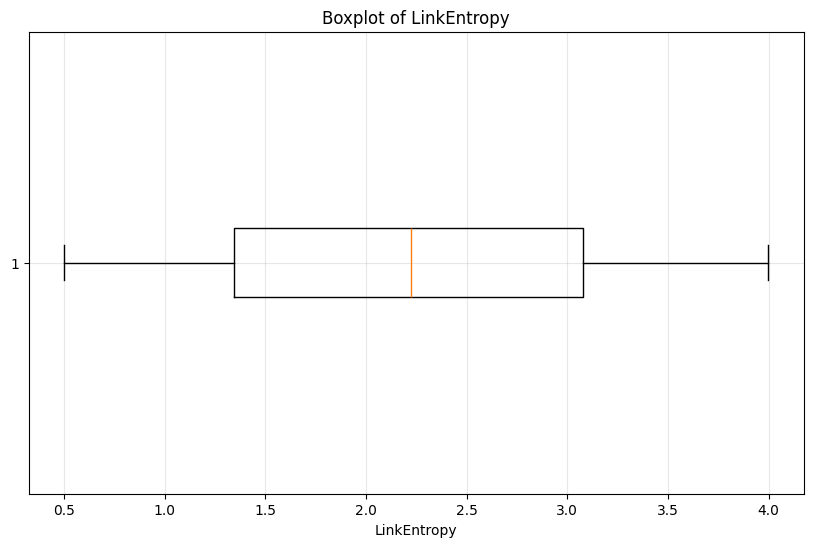

In [15]:
import matplotlib.pyplot as plt

print("="*60)
print("QUARTILE ANALYSIS: LinkEntropy")
print("="*60)

# Calculate quartiles

quartiles = df3.approxQuantile(
    "LinkEntropy",
    [0.25,0.50,0.75],
    0
)

Q1 = quartiles[0]
Q2 = quartiles[1]
Q3 = quartiles[2]

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1 (25th Percentile)    : {round(Q1,3)}")
print(f"Q2 (Median)             : {round(Q2,3)}")
print(f"Q3 (75th Percentile)    : {round(Q3,3)}")

print(f"\nInterquartile Range     : {round(IQR,3)}")

print(f"Lower Boundary          : {round(lower_bound,3)}")
print(f"Upper Boundary          : {round(upper_bound,3)}")


print("\n" + "="*60)
print("VISUALISATION")
print("="*60)


# Convert to Pandas

entropy_pd = df3.select(
    "LinkEntropy"
).toPandas()


# Boxplot

plt.figure(figsize=(10,6))

plt.boxplot(
    entropy_pd["LinkEntropy"],
    vert=False
)

plt.xlabel("LinkEntropy")
plt.title("Boxplot of LinkEntropy")

plt.grid(alpha=0.3)

plt.show()

# Question 6: Relationship Analysis between LinkEntropy and SuspiciousKeywords

RELATIONSHIP ANALYSIS
+----------+------------------+
|EntropyBin|AverageKeywords   |
+----------+------------------+
|0.0       |4.082539682539682 |
|1.0       |3.9431939978563775|
|2.0       |4.084554678692221 |
|3.0       |4.069160997732427 |
|4.0       |3.968674698795181 |
+----------+------------------+


Pearson Correlation: -0.0023

VISUALISATION


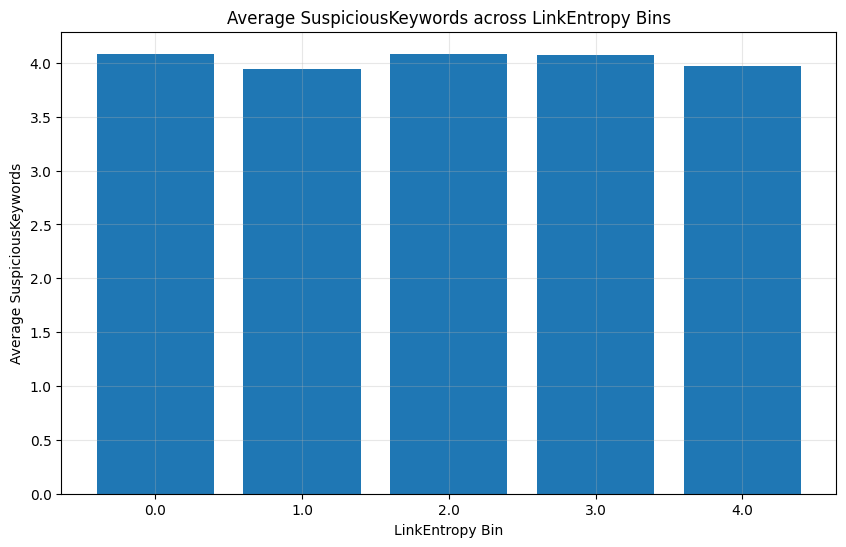

In [17]:
from pyspark.sql.functions import avg
from pyspark.ml.feature import Bucketizer
import matplotlib.pyplot as plt

print("="*60)
print("RELATIONSHIP ANALYSIS")
print("="*60)

# Create bins for LinkEntropy

splits = [0,0.8,1.6,2.4,3.2,4.1]

bucketizer = Bucketizer(
    splits=splits,
    inputCol="LinkEntropy",
    outputCol="EntropyBin"
)

binned_df = bucketizer.transform(df3)

# Average suspicious keywords in each bin

grouped_df = binned_df.groupBy(
    "EntropyBin"
).agg(
    avg("SuspiciousKeywords").alias(
        "AverageKeywords"
    )
)

grouped_df = grouped_df.orderBy(
    "EntropyBin"
)

grouped_df.show(truncate=False)


# Pearson Correlation

correlation = df3.stat.corr(
    "LinkEntropy",
    "SuspiciousKeywords"
)

print("\nPearson Correlation:",
      round(correlation,4))


print("\n" + "="*60)
print("VISUALISATION")
print("="*60)

plot_df = grouped_df.toPandas()

plt.figure(figsize=(10,6))

plt.bar(
    plot_df["EntropyBin"].astype(str),
    plot_df["AverageKeywords"]
)

plt.xlabel("LinkEntropy Bin")
plt.ylabel("Average SuspiciousKeywords")

plt.title(
    "Average SuspiciousKeywords across LinkEntropy Bins"
)

plt.grid(alpha=0.3)

plt.show()

# Question 7: Spark SQL Analysis

In [ ]:
print("="*60)
print("SPARK SQL QUERY ANALYSIS")
print("="*60)

# Create temporary SQL view

df3.createOrReplaceTempView(
    "email_data"
)

# SQL query

query_result = spark.sql("""

SELECT
    AccountAge,
    SenderReputation

FROM email_data

WHERE AccountAge < 50
AND SenderReputation > 100

""")

# Count matching records

record_count = query_result.count()

print(f"Matching records found: {record_count}")

print("\nQuery Results Preview:")
query_result.show(10, truncate=False)

SPARK SQL QUERY ANALYSIS
Matching records found: 874

Query Results Preview:
+----------+----------------+
|AccountAge|SenderReputation|
+----------+----------------+
|11        |195             |
|17        |133             |
|6         |144             |
|1         |149             |
|23        |149             |
|23        |103             |
|12        |173             |
|2         |143             |
|4         |119             |
|42        |193             |
+----------+----------------+
only showing top 10 rows


# Question 8: Decision Tree Classification

## Data Preparation